## Importing & Cleaning Data

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('Hotel_bookings_final.csv')
print(df.shape)
print(df.head())

(30000, 24)
   customer_id  property_id           city  star_rating booking_date  \
0          492            3  San Francisco            4   2024-04-01   
1          180            3         Dallas            3   2024-04-01   
2           50            5         Dallas            3   2024-04-01   
3          294            3        Orlando            4   2024-04-01   
4           40            5        Seattle            5   2024-04-01   

  check_in_date check_out_date room_type  num_rooms_booked stay_type  ...  \
0    2024-05-24     2024-05-26  Standard                 1   Leisure  ...   
1    2024-05-10     2024-05-17    Deluxe                 1   Leisure  ...   
2    2024-05-31     2024-06-05    Deluxe                 1  Business  ...   
3    2024-04-18     2024-04-24    Deluxe                 3   Leisure  ...   
4           NaN            NaN    Deluxe                 1   Leisure  ...   

  selling_price  payment_method  refund_status  refund_amount  \
0         25342          Pa

In [2]:
print(df.dtypes)
print(df.columns.tolist())

customer_id             int64
property_id             int64
city                   object
star_rating             int64
booking_date           object
check_in_date          object
check_out_date         object
room_type              object
num_rooms_booked        int64
stay_type              object
booking_channel        object
booking_value         float64
costprice               int64
markup                  int64
selling_price           int64
payment_method         object
refund_status          object
refund_amount         float64
channel_of_booking     object
booking_status         object
travel_date            object
cashback              float64
coupon_redeem         float64
Coupon USed?           object
dtype: object
['customer_id', 'property_id', 'city', 'star_rating', 'booking_date', 'check_in_date', 'check_out_date', 'room_type', 'num_rooms_booked', 'stay_type', 'booking_channel', 'booking_value', 'costprice', 'markup', 'selling_price', 'payment_method', 'refund_status', 'ref

In [3]:
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

customer_id              0
property_id              0
city                     0
star_rating              0
booking_date             0
check_in_date         5468
check_out_date        5468
room_type                0
num_rooms_booked         0
stay_type                0
booking_channel          0
booking_value            0
costprice                0
markup                   0
selling_price            0
payment_method           0
refund_status            0
refund_amount            0
channel_of_booking       0
booking_status           0
travel_date              0
cashback                 0
coupon_redeem            0
Coupon USed?             0
dtype: int64
Duplicates: 0


In [4]:
df['booking_date'] = pd.to_datetime(df['booking_date'])
df['travel_date'] = pd.to_datetime(df['travel_date'])
df['check_in_date'] = pd.to_datetime(df['check_in_date'], errors='coerce')
df['check_out_date'] = pd.to_datetime(df['check_out_date'], errors='coerce')

In [5]:
df['is_cancelled'] = (df['booking_status'] == 'Cancelled').astype(int)
df['length_of_stay'] = (df['check_out_date'] - df['check_in_date']).dt.days
df['lead_time'] = (df['travel_date'] - df['booking_date']).dt.days
df['booking_month'] = df['booking_date'].dt.to_period('M').astype(str)
df['travel_month'] = df['travel_date'].dt.strftime('%b')
df['profit'] = df['selling_price'] - df['costprice']

In [13]:
print(df['booking_status'].value_counts())
print(df['booking_channel'].value_counts())
print(df['room_type'].value_counts())
print(df[['booking_value', 'selling_price', 'profit', 'length_of_stay']].describe())

booking_status
Confirmed    21672
Cancelled     6070
Failed        2258
Name: count, dtype: int64
booking_channel
Web             15001
Mobile App      12009
Travel Agent     2990
Name: count, dtype: int64
room_type
Standard    16552
Deluxe      10478
Suite        2970
Name: count, dtype: int64
       booking_value  selling_price       profit  length_of_stay
count   30000.000000   30000.000000  30000.00000    24532.000000
mean    25080.525454   29504.818500   6963.32440        4.006848
std     11587.369335   12119.627338   2860.10657        2.001231
min      1279.770000    5003.000000   1181.00000        1.000000
25%     15922.712500   19750.500000   4661.75000        2.000000
50%     24736.145000   29752.500000   7021.50000        4.000000
75%     33570.000000   39826.000000   9399.00000        6.000000
max     67764.460000   50000.000000  11800.00000        7.000000


In [7]:
print("Overall cancellation rate:", df['is_cancelled'].mean() * 100, "%")
print(df.groupby('booking_channel')['is_cancelled'].mean() * 100)
print(df.groupby('room_type')['is_cancelled'].mean() * 100)

Overall cancellation rate: 20.233333333333334 %
booking_channel
Mobile App      21.558831
Travel Agent    27.926421
Web             17.638824
Name: is_cancelled, dtype: float64
room_type
Deluxe      16.024050
Standard    23.302320
Suite       17.979798
Name: is_cancelled, dtype: float64


In [8]:
df['booking_status'].value_counts(normalize=True) * 100

booking_status
Confirmed    72.240000
Cancelled    20.233333
Failed        7.526667
Name: proportion, dtype: float64

In [9]:
df.groupby('star_rating')['is_cancelled'].mean() * 100

star_rating
2    19.766277
3    20.200765
4    19.993352
5    21.259144
Name: is_cancelled, dtype: float64

In [10]:
df.groupby('travel_month')['booking_status'].count().sort_values(ascending=False)

travel_month
Aug    5039
Jul    4441
Jun    3919
Sep    3787
May    3675
Apr    3088
Oct    1689
Dec    1501
Nov    1395
Mar    1127
Jan     339
Name: booking_status, dtype: int64

In [11]:
df.groupby('booking_channel')['booking_value'].mean().round(2)

booking_channel
Mobile App      21351.29
Travel Agent    24453.97
Web             28190.84
Name: booking_value, dtype: float64

##Phase-2

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

## Charts
##Chart 1 — Cancellation rate by booking channel (bar chart)

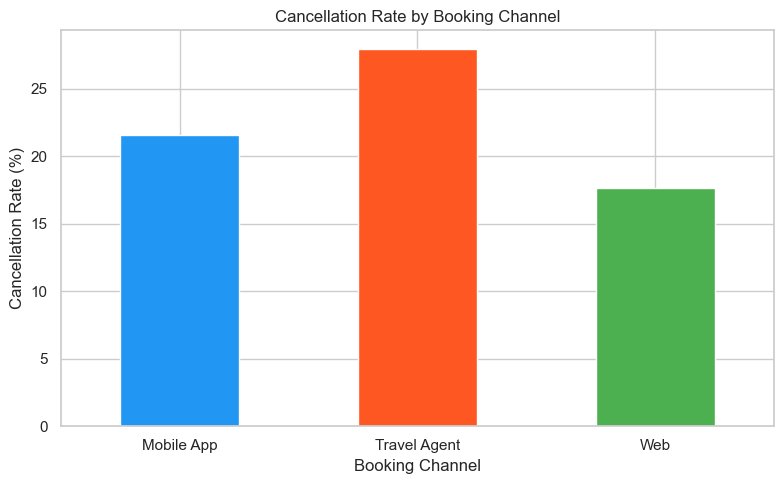

In [15]:
cancel_by_channel = df.groupby('booking_channel')['is_cancelled'].mean() * 100

plt.figure(figsize=(8,5))
cancel_by_channel.plot(kind='bar', color=['#2196F3','#FF5722','#4CAF50'])
plt.title('Cancellation Rate by Booking Channel')
plt.ylabel('Cancellation Rate (%)')
plt.xlabel('Booking Channel')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart1_cancel_by_channel.png', dpi=150)
plt.show()

In [16]:
##Chart 2 — Cancellation rate by room type (bar chart)

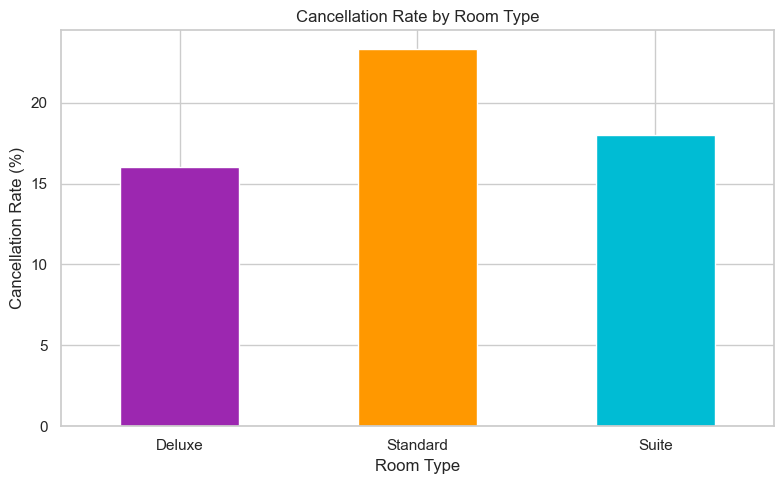

In [17]:
cancel_by_room = df.groupby('room_type')['is_cancelled'].mean() * 100

plt.figure(figsize=(8,5))
cancel_by_room.plot(kind='bar', color=['#9C27B0','#FF9800','#00BCD4'])
plt.title('Cancellation Rate by Room Type')
plt.ylabel('Cancellation Rate (%)')
plt.xlabel('Room Type')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart2_cancel_by_room.png', dpi=150)
plt.show()

In [19]:
##Chart 3 — Booking volume by travel month (line chart)

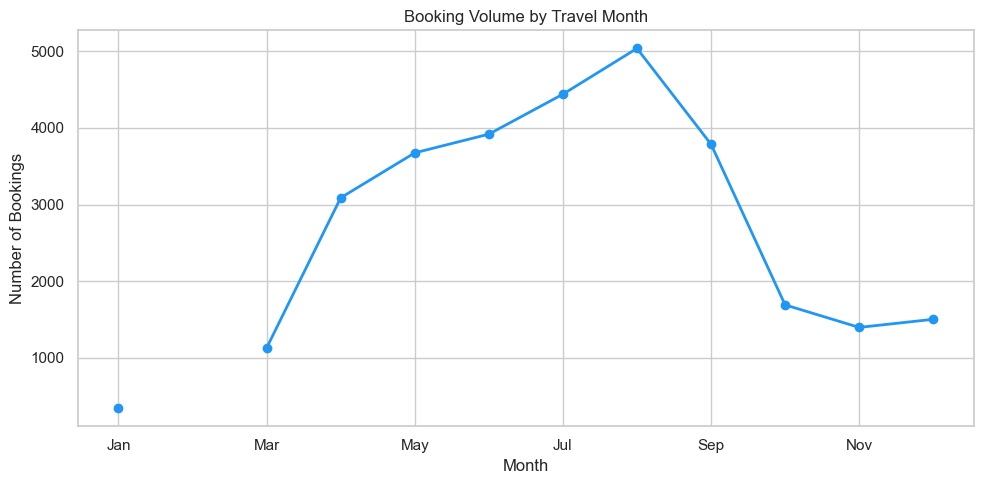

In [18]:
# Order months correctly
month_order = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

monthly = df.groupby('travel_month').size().reindex(month_order)

plt.figure(figsize=(10,5))
monthly.plot(kind='line', marker='o', color='#2196F3', linewidth=2)
plt.title('Booking Volume by Travel Month')
plt.ylabel('Number of Bookings')
plt.xlabel('Month')
plt.tight_layout()
plt.savefig('chart3_monthly_volume.png', dpi=150)
plt.show()

In [21]:
##Chart 4 — Avg booking value by channel (bar chart)

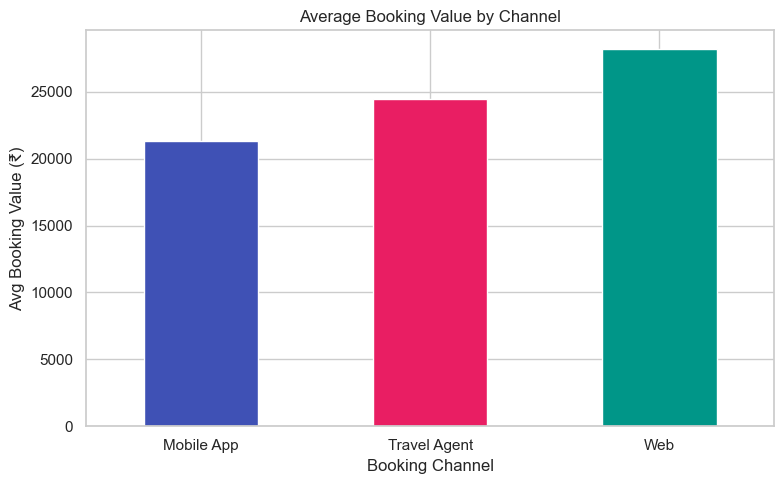

In [20]:
avg_value = df.groupby('booking_channel')['booking_value'].mean().round(2)

plt.figure(figsize=(8,5))
avg_value.plot(kind='bar', color=['#3F51B5','#E91E63','#009688'])
plt.title('Average Booking Value by Channel')
plt.ylabel('Avg Booking Value (₹)')
plt.xlabel('Booking Channel')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart4_avg_value_channel.png', dpi=150)
plt.show()

In [22]:
##Chart 5 — Booking mix: channel vs room type (stacked bar)

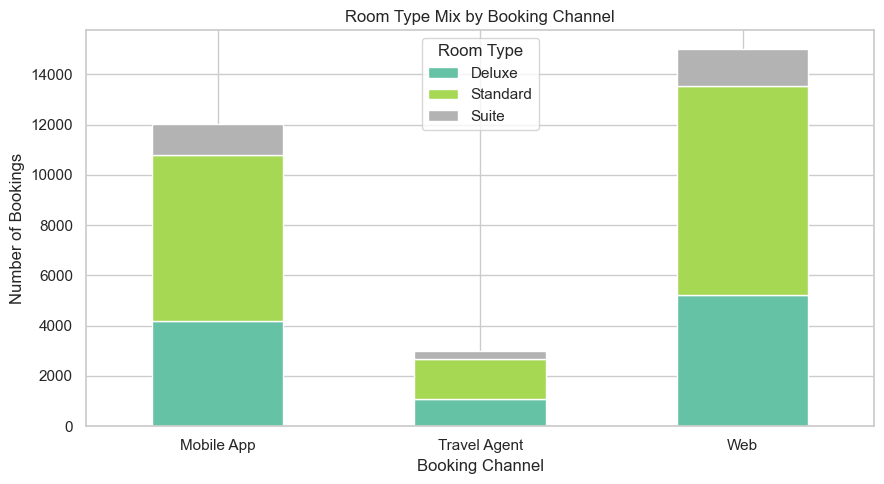

In [23]:
mix = df.groupby(['booking_channel','room_type']).size().unstack()

mix.plot(kind='bar', stacked=True, figsize=(9,5),
         colormap='Set2')
plt.title('Room Type Mix by Booking Channel')
plt.ylabel('Number of Bookings')
plt.xlabel('Booking Channel')
plt.xticks(rotation=0)
plt.legend(title='Room Type')
plt.tight_layout()
plt.savefig('chart5_channel_room_mix.png', dpi=150)
plt.show()

In [24]:
##Chart 6 — Cancellation rate by star rating (bar chart)

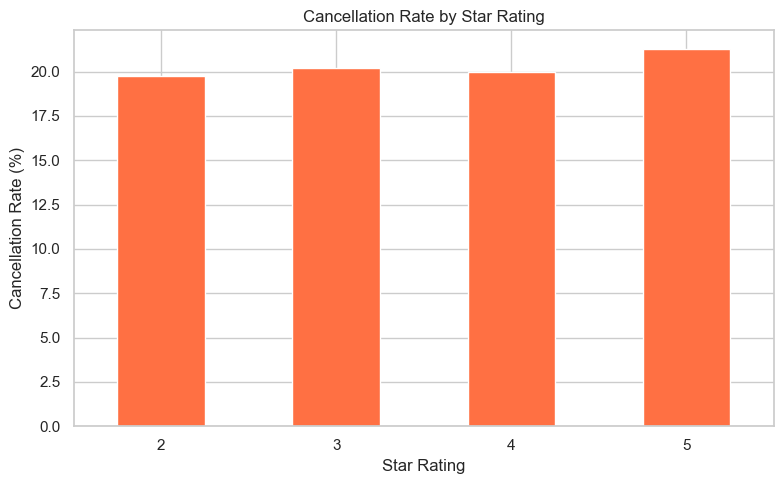

In [25]:
cancel_by_star = df.groupby('star_rating')['is_cancelled'].mean() * 100

plt.figure(figsize=(8,5))
cancel_by_star.plot(kind='bar', color='#FF7043')
plt.title('Cancellation Rate by Star Rating')
plt.ylabel('Cancellation Rate (%)')
plt.xlabel('Star Rating')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart6_cancel_by_star.png', dpi=150)
plt.show()

In [26]:
##Chart 7 — Monthly cancellation rate trend (line chart)

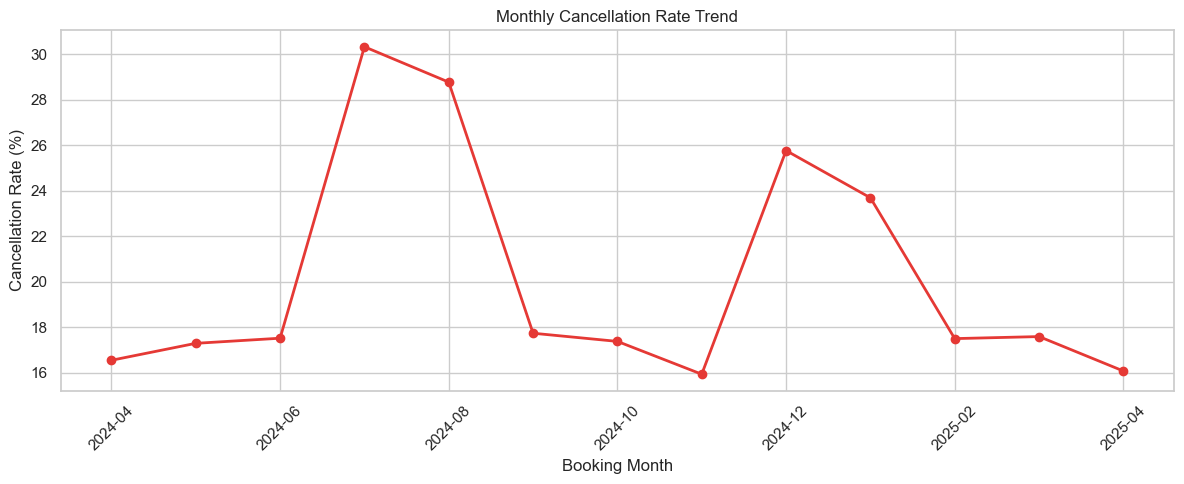

In [27]:
monthly_cancel = df.groupby('booking_month')['is_cancelled'].mean() * 100

plt.figure(figsize=(12,5))
monthly_cancel.plot(kind='line', marker='o', color='#E53935', linewidth=2)
plt.title('Monthly Cancellation Rate Trend')
plt.ylabel('Cancellation Rate (%)')
plt.xlabel('Booking Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart7_monthly_cancel_trend.png', dpi=150)
plt.show()

In [28]:
##Chart 8 — Booking volume by star rating

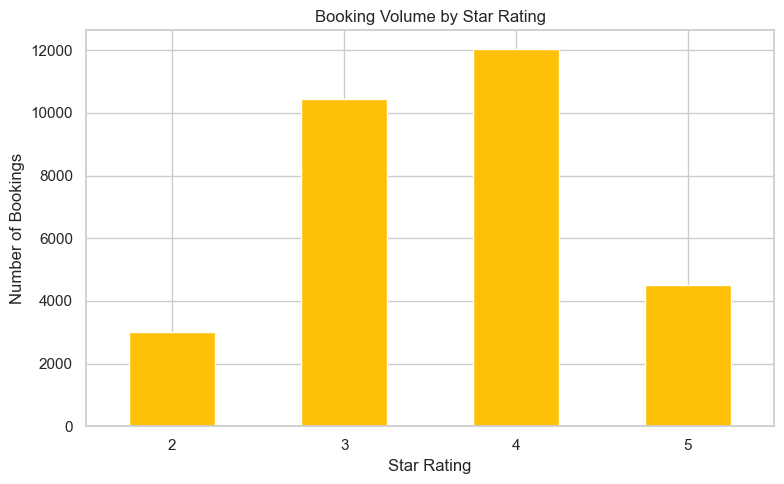

In [29]:
bookings_by_star = df.groupby('star_rating').size()

plt.figure(figsize=(8,5))
bookings_by_star.plot(kind='bar', color='#FFC107')
plt.title('Booking Volume by Star Rating')
plt.ylabel('Number of Bookings')
plt.xlabel('Star Rating')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart8_volume_by_star.png', dpi=150)
plt.show()

In [30]:
##Chart 9 — Booking volume by room type

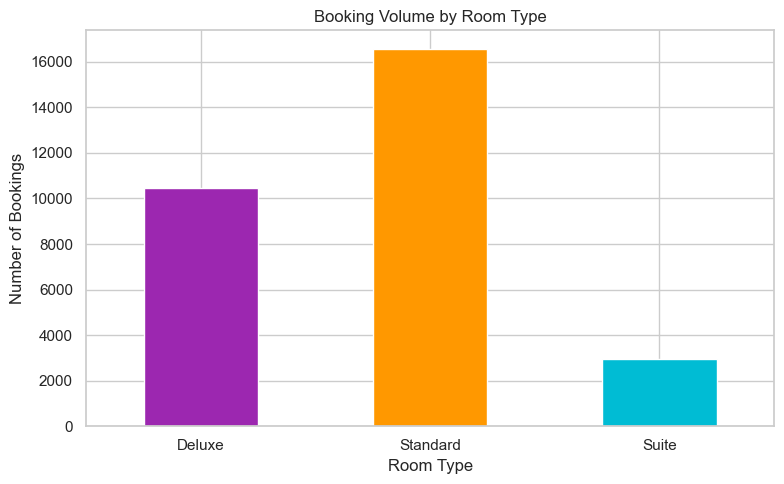

In [31]:
bookings_by_room = df.groupby('room_type').size()

plt.figure(figsize=(8,5))
bookings_by_room.plot(kind='bar', color=['#9C27B0','#FF9800','#00BCD4'])
plt.title('Booking Volume by Room Type')
plt.ylabel('Number of Bookings')
plt.xlabel('Room Type')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart9_volume_by_room.png', dpi=150)
plt.show()

In [32]:
##Chart 10 — Stay type mix (Leisure vs Business)

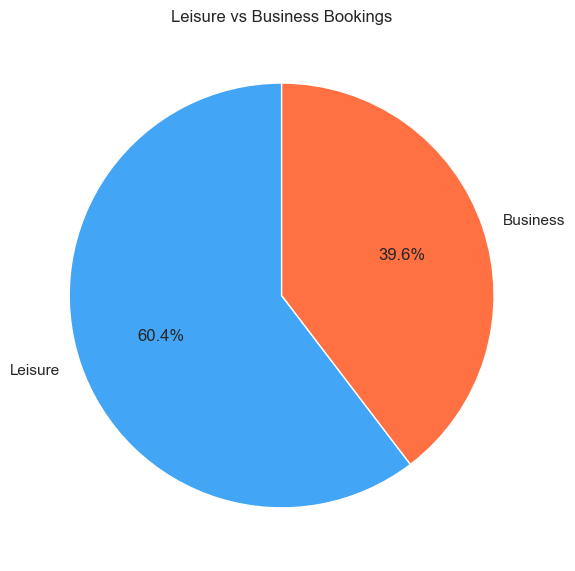

In [33]:
stay_mix = df['stay_type'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(stay_mix, labels=stay_mix.index, autopct='%1.1f%%',
        colors=['#42A5F5','#FF7043'], startangle=90)
plt.title('Leisure vs Business Bookings')
plt.tight_layout()
plt.savefig('chart10_stay_type_mix.png', dpi=150)
plt.show()

In [34]:
##Chart 11 — Avg booking value by travel month

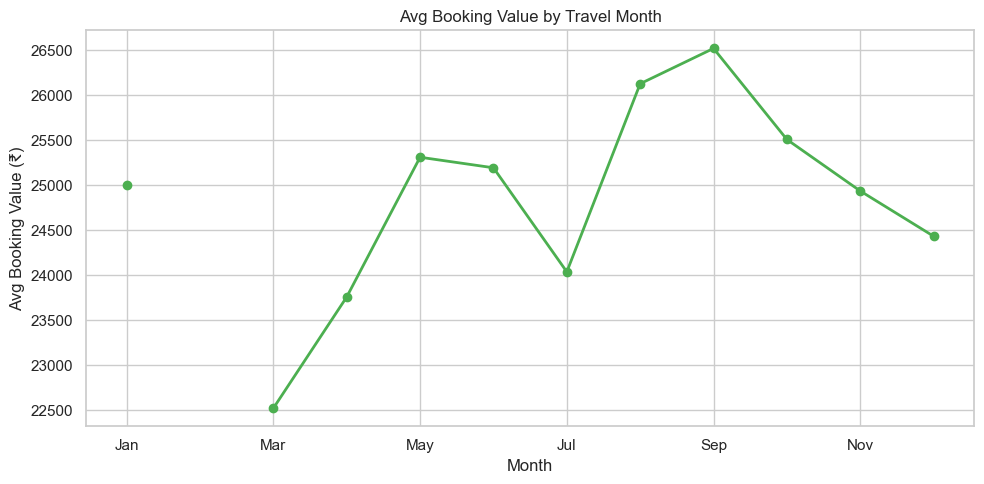

In [35]:
month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

avg_value_month = df.groupby('travel_month')['booking_value'].mean().reindex(month_order)

plt.figure(figsize=(10,5))
avg_value_month.plot(kind='line', marker='o', color='#4CAF50', linewidth=2)
plt.title('Avg Booking Value by Travel Month')
plt.ylabel('Avg Booking Value (₹)')
plt.xlabel('Month')
plt.tight_layout()
plt.savefig('chart11_avg_value_month.png', dpi=150)
plt.show()

In [36]:
##Chart 12 — Avg length of stay by room type

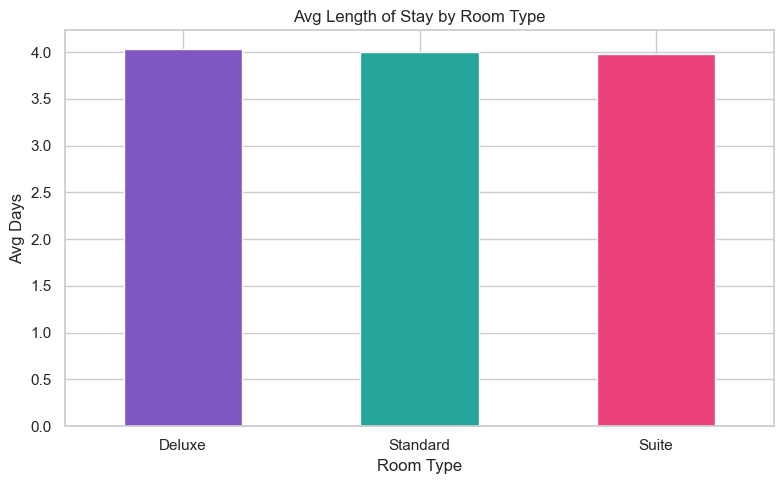

In [37]:
los_by_room = df.groupby('room_type')['length_of_stay'].mean().round(2)

plt.figure(figsize=(8,5))
los_by_room.plot(kind='bar', color=['#7E57C2','#26A69A','#EC407A'])
plt.title('Avg Length of Stay by Room Type')
plt.ylabel('Avg Days')
plt.xlabel('Room Type')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart12_los_by_room.png', dpi=150)
plt.show()

In [39]:
##Chart 13 — Lead time distribution

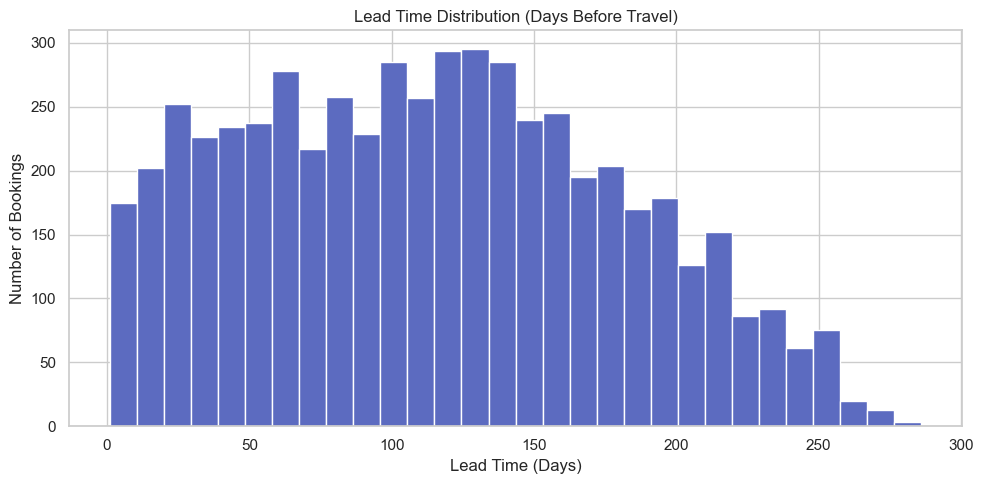

In [40]:
# Only positive lead times (booked before travel)
lead = df[df['lead_time'] > 0]['lead_time']

plt.figure(figsize=(10,5))
plt.hist(lead, bins=30, color='#5C6BC0', edgecolor='white')
plt.title('Lead Time Distribution (Days Before Travel)')
plt.ylabel('Number of Bookings')
plt.xlabel('Lead Time (Days)')
plt.tight_layout()
plt.savefig('chart13_lead_time_dist.png', dpi=150)
plt.show()

In [41]:
##Chart 14 — Profit by booking channel

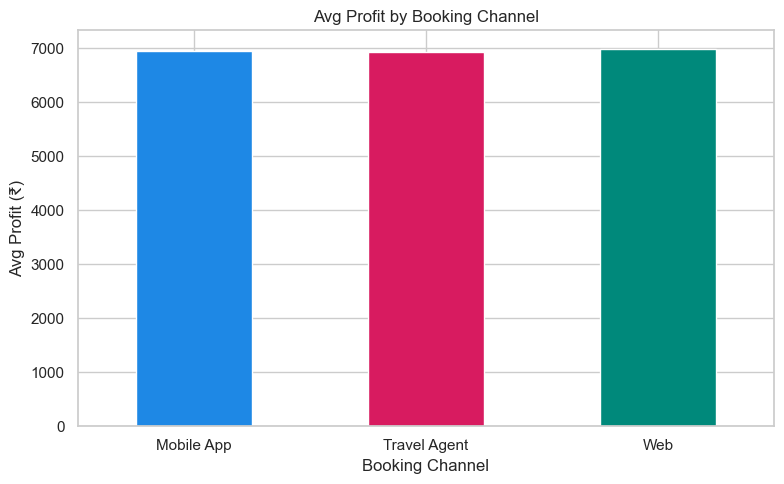

In [42]:
profit_by_channel = df.groupby('booking_channel')['profit'].mean().round(2)

plt.figure(figsize=(8,5))
profit_by_channel.plot(kind='bar', color=['#1E88E5','#D81B60','#00897B'])
plt.title('Avg Profit by Booking Channel')
plt.ylabel('Avg Profit (₹)')
plt.xlabel('Booking Channel')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart14_profit_by_channel.png', dpi=150)
plt.show()

In [43]:
##Chart 15 — Profit by room type

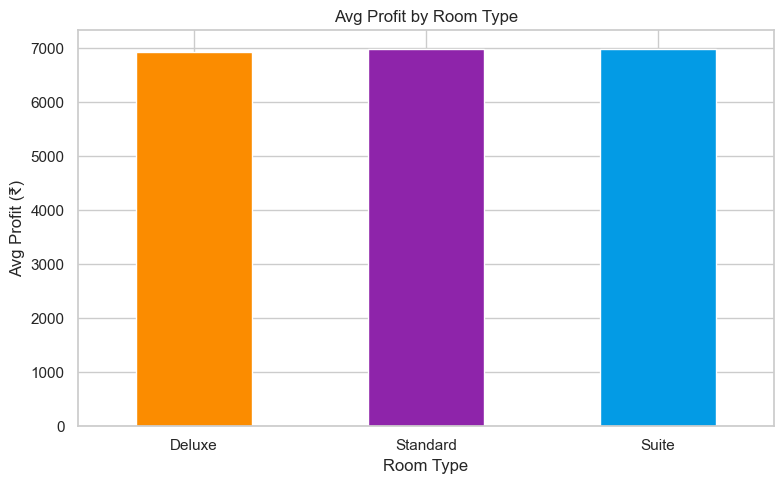

In [44]:
profit_by_room = df.groupby('room_type')['profit'].mean().round(2)

plt.figure(figsize=(8,5))
profit_by_room.plot(kind='bar', color=['#FB8C00','#8E24AA','#039BE5'])
plt.title('Avg Profit by Room Type')
plt.ylabel('Avg Profit (₹)')
plt.xlabel('Room Type')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart15_profit_by_room.png', dpi=150)
plt.show()

In [45]:
##Chart 16 — Coupon usage vs cancellation rate

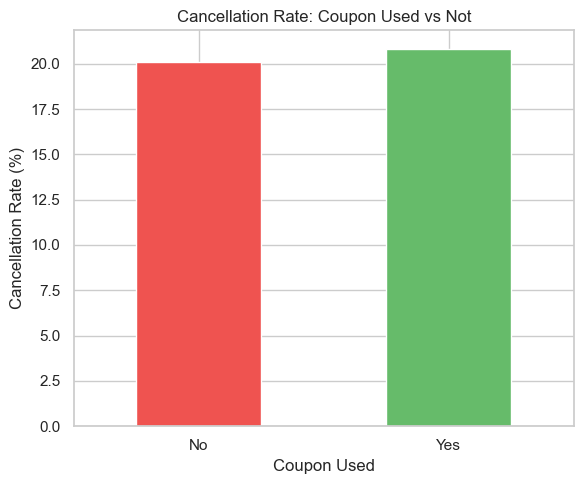

In [48]:
coupon_cancel = df.groupby('Coupon USed?')['is_cancelled'].mean() * 100

plt.figure(figsize=(6,5))
coupon_cancel.plot(kind='bar', color=['#EF5350','#66BB6A'])
plt.title('Cancellation Rate: Coupon Used vs Not')
plt.ylabel('Cancellation Rate (%)')
plt.xlabel('Coupon Used')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart16_coupon_cancel.png', dpi=250)
plt.show()

In [49]:
##Chart 17 — Payment method vs cancellation rate

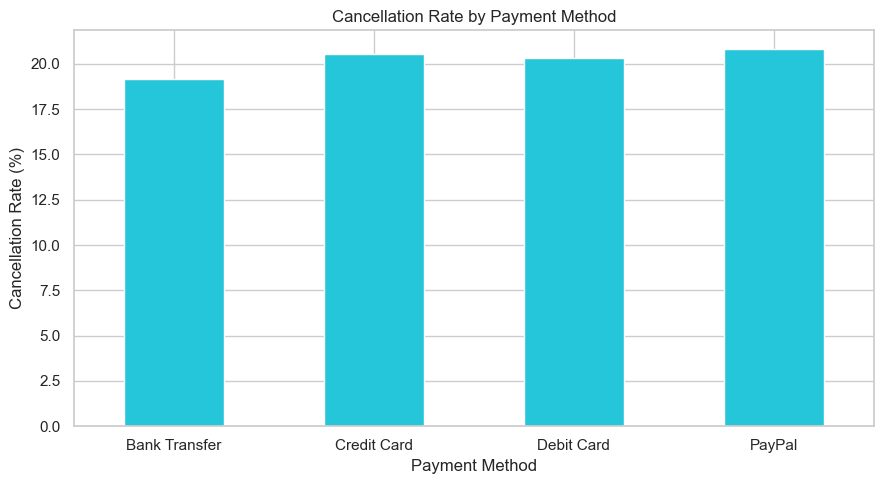

In [50]:
payment_cancel = df.groupby('payment_method')['is_cancelled'].mean() * 100

plt.figure(figsize=(9,5))
payment_cancel.plot(kind='bar', color='#26C6DA')
plt.title('Cancellation Rate by Payment Method')
plt.ylabel('Cancellation Rate (%)')
plt.xlabel('Payment Method')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart17_payment_cancel.png', dpi=150)
plt.show()